# 005 — Strain and Stress Analysis

Written by Jean-Baptiste Jacob  

Last updated: 23/02/2026

---

Use `grain_stress_fit.py` module to map elastic strain and stress across the sample. It computes strain and stress tensors across the whole indexed map, handles conversion between full tensor and Voigt notation and manages rotations between crystal and sample reference frames. 

Strain is computed as finite strain (Green-Lagrange strain tensor) using ImageD11.finite_strain.

Stress is computed from the strain tensor using Hooke’s law expressed in Voigt notation: $\mathbf{S} = \mathbf{C} . \mathbf{E}$

where:
- $\mathbf{S}$ is the stress tensor  
- $\mathbf{E}$ is the strain tensor  
- $\mathbf{C}$ is the stiffness tensor (elastic constants), which depends on crystal symmetry  



---

## Important Considerations

**Reference Unit Cell (B₀)**

The choice of the reference unit cell **B₀** is critical. It may differ from the unit cell used during indexing (e.g. taken from a CIF file and not perfectly fitted to the experiment) For **relative strain variations**, using an average unit cell across the sample is often sufficient, but for **absolute strain or stress states** (e.g. to map grains in tension vs compression), an accurate calibration of B₀ is required.

**Reference Frame**

Strain tensors are expressed in a **Cartesian reference frame**, typically the crystal frame, or the sample frame. The sample frame is usually the one of interest, e.g. when doing, a loading experiment, but stress calculation are handled in the crystal coordinate systems. Care is needed for defining the crystal reference frame: For crystals with orthogonal axes (cubic, tetragonal, orthorhombic), this is straightforward, as the crystal axes $(a,b,c)$ naturally define an orthogonal basis. For lower-symmetry systems, ambiguity arises in how the orthonormal frame is aligned with crystal directions, which can lead to misleading interpretations. See for instance this discussion for quartz: [#194](https://github.com/FABLE-3DXRD/ImageD11/issues/194).

**Stress and Elastic Constants**

The stiffness tensor $\mathbf{C}$ is defined in a specific coordinate system tied to crystal directions. An incorrect choice of reference frame relative to crystal axes will result in incorrect stress values.

**Conventions**

- In Voigt notation, remember the factor of **2 for shear strain components**.  
- In some fields (e.g. geomechanics), the sign convention differs:
  - **Engineering convention**: tension is positive  
  - **Geoscience convention**: compression is positive  

Make sure to use a consistent convention.

---
## Requirements

- A **pixel map** (`xmap`) or a stack of pixel maps with local indexing performed for at least one phase  
- Grain reconstruction completed (required for grain-level strain/stress)  
- Elastic constants $C_{ij}$ for the phase(s) of interest  


### Load data 

In [1]:
import sys

# python environment stuff
IMAGED11_PATH = '/home/esrf/jean1994b'  # None means do not use git, otherwise enter the name of the folder to use for the git checkout "ImageD11" or "ImageD11_version_xx", etc
CHECKOUT_PATH = 'ImageD11'  # the name of the git checkout folder within path. None means guess


if IMAGED11_PATH is not None:
    if '/data/id11/nanoscope' not in sys.path:
        sys.path.append('/data/id11/nanoscope')
    import install_ImageD11_from_git
    install_ImageD11_from_git.setup_ImageD11_from_git(IMAGED11_PATH,CHECKOUT_PATH)

# Setting path via: 
sys.path.insert(0, /home/esrf/jean1994b/ImageD11 )
# Running from: /home/esrf/jean1994b/ImageD11/ImageD11/__init__.py


In [2]:
import os, glob
import numpy as np
import matplotlib.pyplot as pl
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from tqdm import tqdm

import ImageD11.sinograms.dataset, ImageD11.columnfile, ImageD11.stress, ImageD11.grain

from pf3dxrd.pf3dxrd import utils, pixelmap, friedel_pairs, crystal_structure, grain_stress_fit

from uvw import RectilinearGrid, DataArray

%matplotlib ipympl
%load_ext autoreload
%autoreload 2

In [3]:
# paths
data_dir = '/home/esrf/jean1994b/test_datasets/SI3/'
#data_dir = '/home/esrf/jean1994b/test_datasets/C18A_01_z180/'

datasets = ['SI3_DT360Z5480']
#datasets = ['C18A_01_z180']

parfile= data_dir+'/SI3.par'
#parfile= data_dir+'/C18A_01.par'

# phase to process
phase = 'quartz'


In [4]:
def load_data(dsname):
    xmappath = os.path.join(data_dir,dsname+'_xmap_strain.h5')
    dspath   = os.path.join(data_dir,dsname+'_dataset.h5')

    if os.path.exists(os.path.join(data_dir,dsname+'_xmap_strain.h5')):
        xmappath = os.path.join(data_dir,dsname+'_xmap_strain.h5')
    else:
        xmappath = os.path.join(data_dir,dsname+'_xmap.h5')
    
    dspath   = os.path.join(data_dir,dsname+'_dataset.h5')
    
    xmap = pixelmap.load_from_hdf5(xmappath)
    ds = ImageD11.sinograms.dataset.load(dspath)

    return xmap, ds

In [5]:
%%time
# load data from all xmaps and store them in a big dict

# define dict to store data, labels, etc.
keys = ['dsname', 'ds', 'xmap']
vals = [[] for _ in range(len(keys))]        
xmap_dict = dict(zip(keys,vals))        
    
# load xmaps
for ds in datasets:
    xmap, ds = load_data(ds)
    xmap_dict['ds'].append(ds)
    xmap_dict['dsname'].append(ds.dsname)
    xmap_dict['xmap'].append(xmap)

xmap_dict['dsname']

CPU times: user 898 ms, sys: 54.8 ms, total: 953 ms
Wall time: 782 ms


['SI3_DT360Z5480']

### Define reference unit cell and add elastic constants

#### Get reference unit cell
Strain is computed relative to a reference. This can be the reference unit cell provided in the cif file ("absolute" strain), or the mean across the map or a subdomain, or whatever else you want as long as it makes sense.

In [6]:
# Take reference cell from the cif file: stored in xmap.phases
xmap = xmap_dict['xmap'][0]
B0_cif = xmap.phases.get(phase).cell
B0_cif

array([  4.91921,   4.91921,   5.41186,  90.     ,  90.     , 120.     ])

In [9]:
# Compute Median unit cell over the map. In this case, make sure the averaged cell respects crystal symmetry.
xmap = xmap_dict['xmap'][0]
pm = xmap.get_phase_mask(phase) & (xmap.nindx>0)

# for quartz: trigonal cell (a_mean, a_mean, c_mean, 90, 90, 120). Use median instead of mean, more robust against spurious extreme strain values
uc_med = np.median(xmap.unitcell[pm], axis=0)
a_med = np.array(uc_med[:2]).mean()
B0_med = np.array([a_med, a_med, uc_med[2], 90, 90, 120])
B0_med


# garnet: [a_mean, a_mean, a_mean, 90, 90, 90]
#a_med = np.array(uc_med[:3]).mean()
#B0_med = np.array([a_med, a_med, a_med, 90, 90, 90])
#B0_med

array([  4.91760159,   4.91760159,   5.41035125,  90.        ,
        90.        , 120.        ])

Plot the distribution of unit cell parameters across the map and see how it compares with the median B0 and the B0 from the CIF file

/tmp/ipykernel_2858965/1382910542.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  pl.legend(loc='best')


Text(0.5, 0.98, 'distribution of unit cell parameters - quartz')

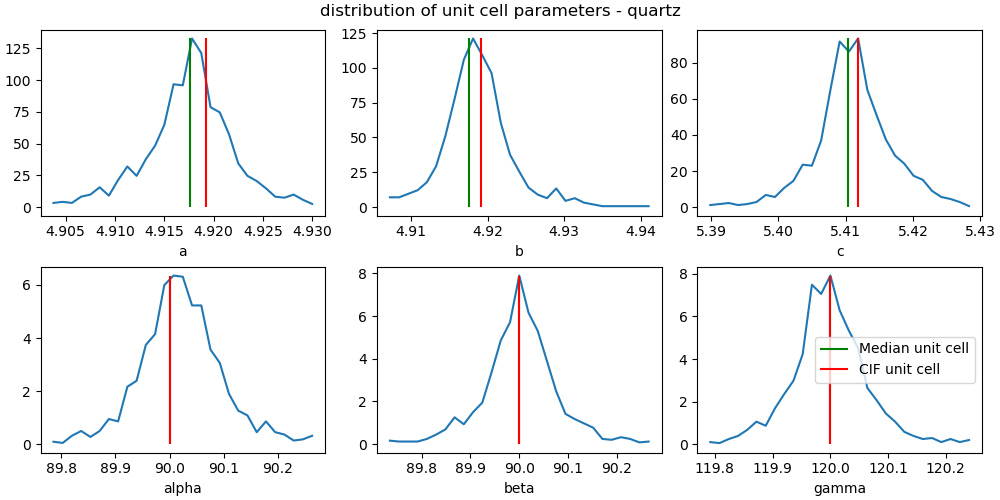

In [10]:
# plot distribution of unit cell parameters to check whether there is someting wrong
cs = xmap.phases.get(phase)

fig, ax = pl.subplots(2,3, figsize=(10,5), layout='constrained')
ax = ax.ravel()
titles = 'a,b,c,alpha,beta,gamma'.split(',')

for i, a in enumerate(ax):
    lo, up = np.percentile(xmap.unitcell[:,i][pm], (1,99))
    bins = np.linspace(lo, up, 30)
    
    h,b = np.histogram(xmap.unitcell[:,i][pm], bins=bins, density=True)
    a.plot(b[1:],h,'-')
    a.set_xlabel(titles[i])
    a.vlines(B0_med[i], ymin = 0, ymax = h.max(), colors='g', label = 'Median unit cell')
    a.vlines(cs.cell[i], ymin = 0, ymax = h.max(), colors='r', label = 'CIF unit cell')
    
    pl.legend(loc='best')
fig.suptitle(f'distribution of unit cell parameters - {phase}')

#### Add elastic constants
The structure of the stiffness matrix depends on crystal symmetry. They are listed in `ImageD11.stress`; For instance, for trigonal quartz, there are seven independant constants to enter.

Elastic constants are added to crystal_structure (CS) objects in CS.elastic_pars. This is dopne directly in xmap, where each phase is defined as a CS object.

In [11]:
# quartz elastic constants (from Heyliger et al., 2003)
c11 = 87.16  * 1e3
c12 = 6.64   * 1e3
c13 = 12.09  * 1e3
c14 = -18.15 * 1e3
c33 = 106.00 * 1e3
c44 = 58.14  * 1e3
c66 = 40.26  * 1e3

for xmap in xmap_dict['xmap']:
    xmap.phases.quartz.add_elastic_constants(symmetry='trigonal_low',
                                             c11=c11,
                                             c12=c12,
                                             c13=c13,
                                             c14=c14,
                                             c33=c33,
                                             c44=c44,
                                             c66=c66)
    
xmap.phases.quartz.elastic_pars.as_dict()

{'c11': 87160.0,
 'c12': 6640.0,
 'c13': 12090.0,
 'c14': -18150.0,
 'c33': 106000.0,
 'c44': 58140.0,
 'c66': 40260.0}

In [104]:
# garnet elastic constants (spessartine, Mittal et al. 2001)
c11 = 313 * 1e3
c12 = 109 * 1e3
c44 = 89  * 1e3
for xmap in xmap_dict['xmap']:
    xmap.phases.garnet.add_elastic_constants(symmetry='cubic', c11=c11, c12=c12, c44=c44)


In [37]:
# orthoclase elastic constants (Waeselmann et al. 2016, Or93)
# "orthorombic" modulii
c11 = 67.8  * 1e3
c22 = 181.2  * 1e3
c33 = 158.4  * 1e3
c44 = 20.1  * 1e3
c55 = 19.4  * 1e3
c66 = 33.1  * 1e3
c12 = 40.4  * 1e3
c13 = 25.0  * 1e3
c23 = 20.6  * 1e3

# other off-diagonal modulii
c15 = -1.1  * 1e3
c25 = -12.9  * 1e3
c35 = 10.6  * 1e3
c46 = -11.6  * 1e3

for xmap in xmap_dict['xmap']:
    xmap.phases.orthoclase.add_elastic_constants(symmetry='trigonal_low',
                                             c11=c11, c12=c12, c13=c13, c14=None, c15=c15, c16=None,
                                             c22=c22, c23=c23, c24=None, c25=c25, c26=None,
                                             c33=c33, c34=None, c35=c35, c36=None,
                                             c44=c44, c45=None, c46=c46,
                                             c55=c55, c56=None,
                                             c66=c66)


### Compute strain and stress

Strain and stress computations are done using the stress solver in ImageD11.stress. Doing all the strain/stress calculation for pixels / grains, extracting the results and updating xmaps can be a bit tedious. The module `grain_stress_fit.py` allows to handle this more easily. 

In [12]:
# Arguments passed to grain_stess_fit.solve_strain_stress function, controls what is computed

kwargs = {'m_exponent'       : 1,               # exponent for the Seth-Hill finite strain tensors E = 1/2m (U^2m - I)
          'reference_frame'  : 'Lab',           # reference frame in which strain and stress are computed. 'Lab' or 'Grain'
          'output_format'    : 'voigt',         # output format for strain / stress. One of 'tensor','voigt','mandel','xfab','default'
          'deviatoric'       : True,            # if True, compute deviatoric strain / stress
          'invariants'       : True,            # if True, compute invariant properties of strain and stress: -I1/3 (Pressure), (√3.J2) (von Mises stress) and strain equivalents
          'principal_components' : True,        # if tryue, compute principal components (sigma1, sigma2, sigma3 eigenvectors)
          'deviatoric_pc'        : False}       # if True, principal components are computed for the deviatoric tensors. Default=False


# compute strain and stress and add results to xmap
for xmap in xmap_dict['xmap']:
    # strain / stress for pixels
    grain_stress_fit.xmap_strain_stress_px(xmap, phase, B0 = B0_med, stress_unit='MPa', overwrite_xmap=True, **kwargs)
    
    # average strain / stress within grains
    grain_stress_fit.xmap_strain_stress_grains(xmap, phase,  B0 = B0_med, stress_unit='MPa', overwrite_xmap=True, **kwargs)

computing strain with d_zero unitcell: [  4.91760159   4.91760159   5.41035125  90.          90.
 120.        ]
computing deformation gradient tensor...
computing strain and stress...
computing additional properties
converting tensors to vecs...
computing strain with d_zero unitcell: [  4.91760159   4.91760159   5.41035125  90.          90.
 120.        ]
computing deformation gradient tensor...
computing strain and stress...
computing additional properties
converting tensors to vecs...


37it [00:00, 117746.02it/s]
94it [00:00, 49474.79it/s]
37it [00:00, 152445.23it/s]
94it [00:00, 51504.19it/s]
37it [00:00, 145991.77it/s]
94it [00:00, 46064.33it/s]
37it [00:00, 222973.06it/s]
94it [00:00, 171121.78it/s]
37it [00:00, 157552.54it/s]
94it [00:00, 54224.26it/s]
37it [00:00, 158518.13it/s]
94it [00:00, 177436.80it/s]
37it [00:00, 271309.87it/s]
94it [00:00, 165587.81it/s]
37it [00:00, 175553.45it/s]
94it [00:00, 54313.90it/s]
37it [00:00, 125152.62it/s]
94it [00:00, 50925.42it/s]
37it [00:00, 167229.79it/s]
94it [00:00, 48578.68it/s]
37it [00:00, 184529.43it/s]
94it [00:00, 148442.99it/s]
37it [00:00, 169605.74it/s]
94it [00:00, 47737.57it/s]


New 'strain_*' and 'stress_*' columns:

- strain/stress_Lab_voigt: (N,6) array with voigt strain / stress components
- eigvals / eigvecs : eigenvectors and eigenvalues of strain/stress tensor -> principal components σ1,σ2,σ3 / ε1,ε2,ε3
- "_d": deviatoric components
- Invariant properties:
  * 'P_hyd', / 'vol' refer to isotropic stress / strain (hydrostatic stress / volumetric strain)
  * 'vM' refers to 'von Mises' strain / stress
- '_g': grain averaged properties

In [13]:
for t in xmap.titles():
    if ('strain' in t) or ('stress' in t):
        print(f'{t}:{xmap.get(t).shape}')

strain_Lab_d_voigt:(12100, 6)
strain_Lab_d_voigt_g:(12100, 6)
strain_Lab_eigvals:(12100, 3)
strain_Lab_eigvals_g:(12100, 3)
strain_Lab_eigvecs:(12100, 3, 3)
strain_Lab_eigvecs_g:(12100, 3, 3)
strain_Lab_vM:(12100,)
strain_Lab_vM_g:(12100,)
strain_Lab_voigt:(12100, 6)
strain_Lab_voigt_g:(12100, 6)
strain_Lab_vol:(12100,)
strain_Lab_vol_g:(12100,)
stress_Lab_P_hyd:(12100,)
stress_Lab_P_hyd_g:(12100,)
stress_Lab_d_voigt:(12100, 6)
stress_Lab_d_voigt_g:(12100, 6)
stress_Lab_eigvals:(12100, 3)
stress_Lab_eigvals_g:(12100, 3)
stress_Lab_eigvecs:(12100, 3, 3)
stress_Lab_eigvecs_g:(12100, 3, 3)
stress_Lab_vM:(12100,)
stress_Lab_vM_g:(12100,)
stress_Lab_voigt:(12100, 6)
stress_Lab_voigt_g:(12100, 6)


### Plot strain / stress maps
visualize the different strain and stress components. There is a special plot function in Pixelmap, to show the six strain/stress components (voigt) in a single figure.

Subscripts 1,2,3 -> (x,y,z).

**Note for colormap:**
For strain/stress components: use a **diverging colormap** with two sequential gradients for positive and negative values. Examples [here](https://matplotlib.org/stable/users/explain/colors/colormaps.html). 'coolwarm' theme or any variation around this is quite standard. 'RdBu' has higher contrast and usually looks better tan 'coolwarm'. 

Avoid simple sequential maps because there is no intuitive central value in it. They can however be used when computing some function of strain / stress like the von Mises equivalent stress, which is strictly positive and increases with strain level.


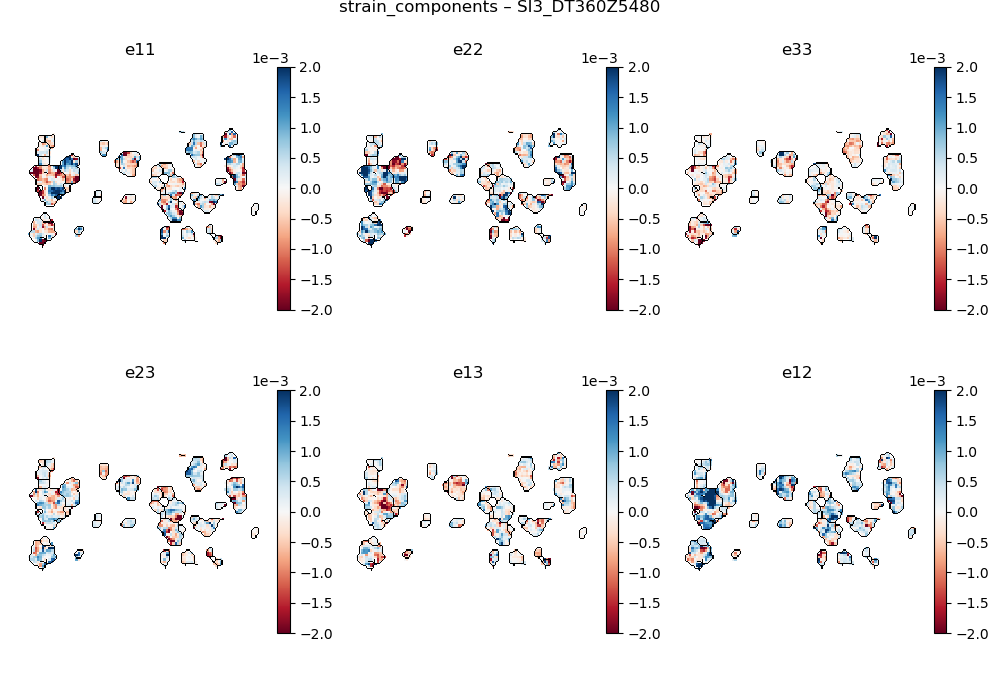

In [15]:
# plot voigt strain/stress components 
xmap = xmap_dict['xmap'][0]

kw = {'cmap':'RdBu',     # diverging colormap
      'norm': mcolors.CenteredNorm(vcenter=0, halfrange=2e-3)}    # centered norm centered on zero. halfrange depends on the data spread. Typically ~1e-3 for strain and ~100 MPa for stress 

# strain
xmap.plot_strain_stress('strain_Lab_d_voigt', phase=phase, autoscale=False, show_gb=True, gb_color='k', gb_res_fact=2, **kw)

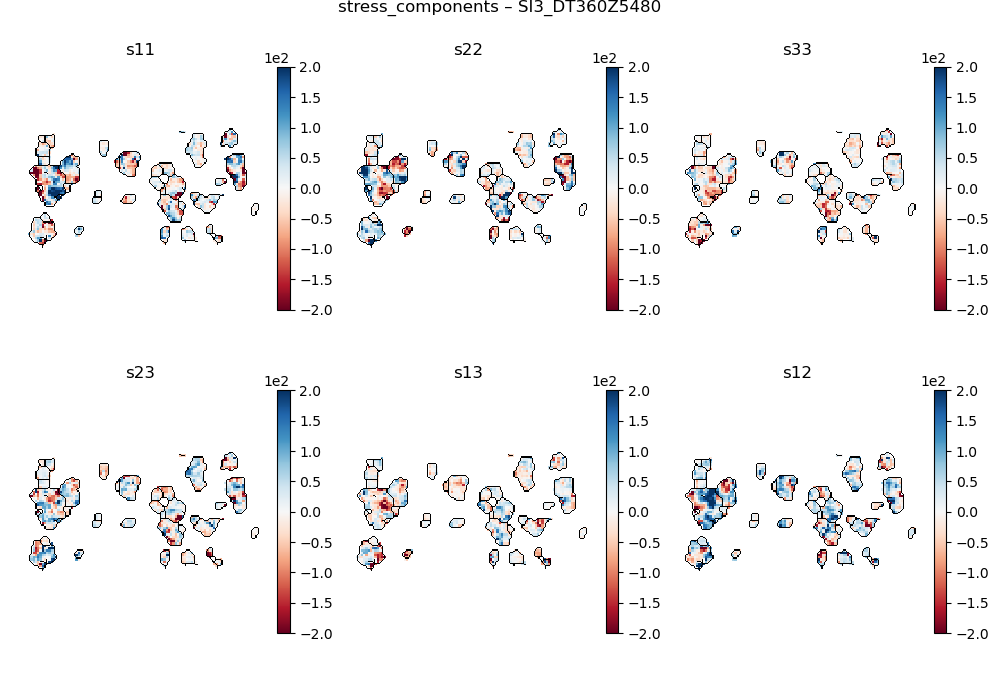

In [17]:
# plot stress to compare
kw = {'cmap':'RdBu', 'norm': mcolors.CenteredNorm(vcenter=0, halfrange=200)}

xmap.plot_strain_stress('stress_Lab_d_voigt', phase=phase, autoscale=False, show_gb=True, gb_color='k', gb_res_fact=2, **kw)

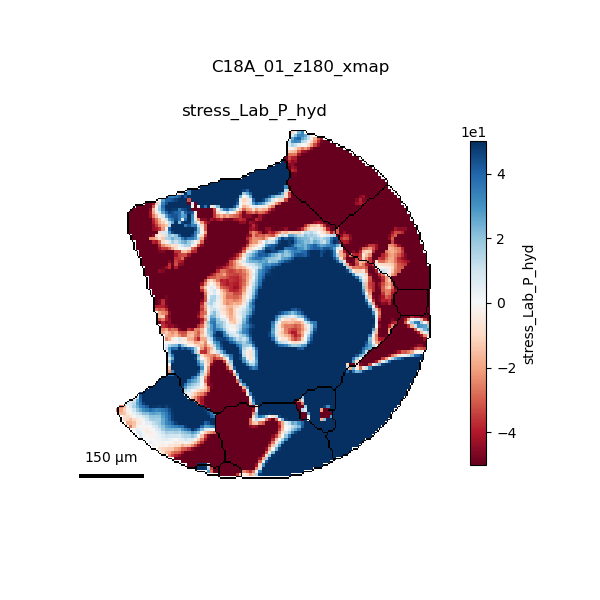

In [112]:
# mean stress (P_hyd)
kw = {'cmap':'RdBu', 'norm': mcolors.CenteredNorm(vcenter=0, halfrange=100)}

xmap.plot('stress_Lab_P_hyd', phase=phase, autoscale=False, show_gb=True, gb_color='k', gb_res_fact=2, **kw)

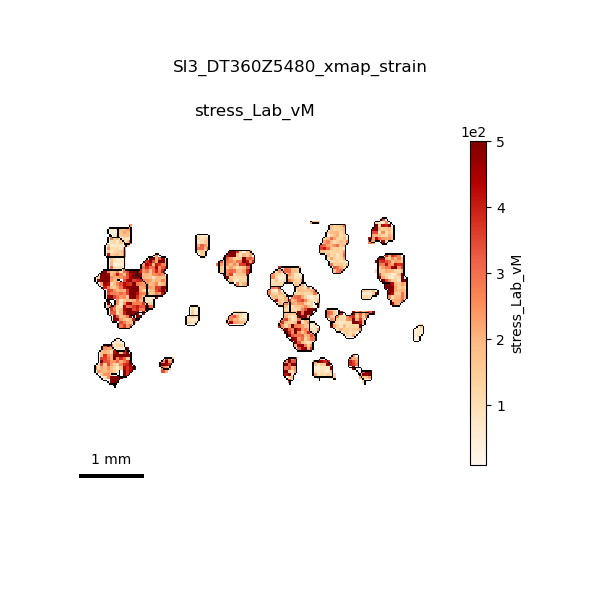

In [20]:
# von Mises stress. here the diverging map is not adapted anymore. We can use another theme
kw = {'cmap':'OrRd', 'vmin':10, 'vmax':500}
#kw = {'cmap':'inferno', 'norm':mcolors.LogNorm(vmin=10, vmax=500)}

xmap.plot('stress_Lab_vM', phase=phase, autoscale=False, show_gb=True, gb_color='k', gb_res_fact=2, **kw)

#### Lambda function plotting

You can also plot a function of the stress components using the 'plot' functiion in pixelmap. For this, simply define the property as a lambda function. Let's try to recalculate von Mises stress. We use here the double dot-product expression:

$\sigma_{\mathrm{vM}} = \sqrt{\frac{3}{2} \; \mathbf{σ}_{\mathrm{dev}} : \mathbf{σ}_{\mathrm{dev}}}$ , 

where $\mathbf{σ}_{\mathrm{dev}}$ is the deviatoric stress tensor.

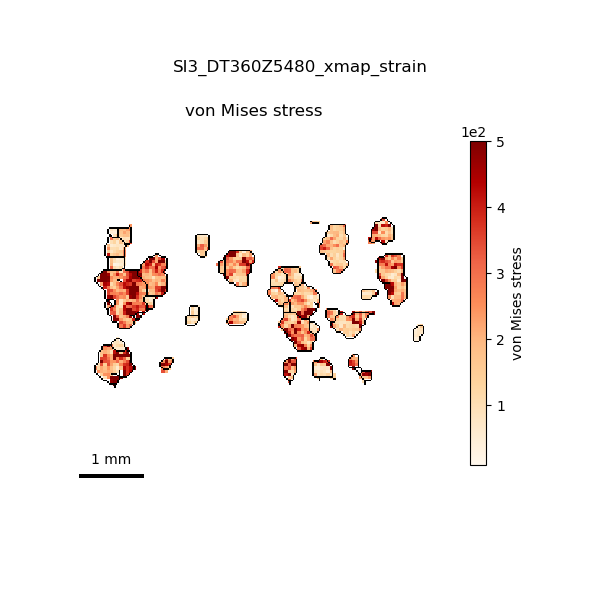

In [21]:
w = np.array([1, 1, 1, 2, 2, 2])   # because we are working with voigt arrays, add factor 2 for the last three components (off-diagonal components in the stress tensor) to sum them twice
svM = lambda xmap: np.sqrt(3/2 * np.sum(w * xmap.stress_Lab_d_voigt**2, axis=-1))

kw = {'cmap':'OrRd', 'vmin':10, 'vmax':500}

xmap.plot(svM, phase=phase, label = 'von Mises stress', autoscale=False, show_gb=True, gb_color='k', gb_res_fact=2, **kw)

### Principal components analysis
The principal stress components are obtained by eigenvalue decomposition of the stress tensor. The stress values are in `stress_Lab_eigvals` and can be plotted using lambda functions. Another useful information is the orientation of the principal stress vectors in `stress_Lab_eigvecs`. Tjhey can be plotted in a pole figure using using the cell below:

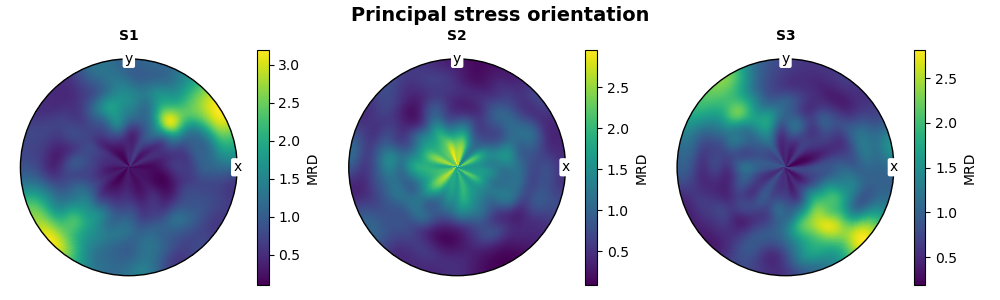

In [23]:
import orix.vector as ovec

# stress orientation polefigures

# figure params
pl.close('all')
prop = lambda xmap: xmap.stress_Lab_eigvecs

col_labels = 'S1,S2,S3'.split(',')
kw = {'cmap':'viridis', 'resolution':.5, 'sigma':8,
      #'norm':mcolors.LogNorm(vmin=0.5, vmax=2.5),
      'colorbar':True}

subplot_kw ={'projection':'stereographic',
             'hemisphere':'upper',
             'polar_resolution':0.5,
             'azimuth_resolution':0.5}

# polefigs
fig, ax = pl.subplots(1,3,figsize=(10,3), subplot_kw=subplot_kw)
fig.suptitle(f'Principal stress orientation', fontsize=14, fontweight="bold")

# loop through stress components and xmaps and make polefigure + rose diagram plots
for i,t in enumerate(col_labels):
    ## get data
    # principal strain/stress vector
    v = prop(xmap)[:,:,i]
    # reproject vectors pointing downward on upper hemisphere
    v = np.multiply(np.sign(v[:,-1])[:, np.newaxis], v)
    # filter data
    sel = xmap.get_phase_mask(phase)
    sel &= xmap.nindx > 0
    # export as orix Vector3d object
    V = ovec.Vector3d(v[sel])
    azim = V.azimuth
    polar = np.degrees(V.polar)
        
    ## Plot polefigs
    a = ax[i]
    a.set_aspect('equal')
    a.set_axis_off()
    a.set_labels("x","y",None)
    a.set_title(col_labels[i], fontsize=10, fontweight='bold', pad=10)
    im = a.pole_density_function(V, rasterized=True, **kw)

fig.tight_layout()
        


### Save xmap and export to vtk
Now we can save the maps with strain and stress components. Default saving skips strain and stress columns so specify `save_mode = 'full'` to make sure they are saved. 
Here we write the map with strain and stress components in a separate hdf5 file. 

In [34]:
# save maps with full strain and stress columns to h5 
for xmap in xmap_dict['xmap']:
    if 'strain' in xmap.h5name:
        xmap.save_to_hdf5(save_mode='full')
    else:
        xmap.save_to_hdf5(xmap.h5name.replace('.h5',f'_strain.h5'), save_mode='full')  

Pixelmap saved to: /home/esrf/jean1994b/test_datasets/SI3/SI3_DT360Z5480_xmap_strain.h5


For 3D stacks, you may also want to visualize the 3D map of strain, stress, or any other measure. For that, we need to stack the 2D maps into a 3D array and save it as a ;vtr file to be opened in Paraview.

In [39]:
# export to vtk file for paraview

def stack_2D_slices(xmap_list, dname):
    """ stack data from 2D z-slices stored in dictionnary and return them as a 3D volume. Required if working with 3D dataset"""
    
    assert all([dname in x.titles() for x in xmap_list]), 'data array is missing in at least one xmap'
    
    # data shape
    x0 = xmap_list[0]
    nx, ny = x0.grid.nx, x0.grid.ny
    array_shape = x0.get(dname).shape
    
    # stack ndarrays
    if len(array_shape) == 1:
        stacked_ndarray = np.array([x.get(dname).reshape(nx,ny) for x in xmap_list])
    else:
        newshape = (nx,ny,) + array_shape[1:]
        stacked_ndarray = np.array([x.get(dname).reshape(newshape) for x in xmap_list])
        
    # swap axes to get z-axis in last coordinates
    stacked_ndarray = np.swapaxes(stacked_ndarray, 0,2)
    print(f'stacked array {dname} : {stacked_ndarray.shape}, {stacked_ndarray.dtype}, NaN: {np.count_nonzero(np.isnan(stacked_ndarray))}')
    
    return stacked_ndarray


def xmap_stack_to_vtk(xmap_stack, coords_z_stack = None, to_skip=None, skip_bulk_grain_props = True, outname=None):
    
    # Grid coordinates
    # x,y
    xmap = xmap_stack[0]
    x, y = xmap.grid.xbins, xmap.grid.ybins
    
    # z
    if coords_z_stack is None:
        px = xmap.grid.pixel_size
        z = np.arange(0,len(xmap_stack)*px,px)
    else:
        assert len(coords_z_stack) == len(xmap_stack)
        z = coords_z_stack
        
    # define properties to skip (not saved): grid index and U/UBI are not saved by default
    to_skip_default = 'xyi,xi,yi,U,UBI'.split(',')
    if to_skip is None:
        to_skip = to_skip_default
    else:
        to_skip.extend(to_skip_default)
        
    # export pixelmap properties to 3D grid
    # file name for output
    if outname is None:
        outname = xmap.h5name.replace('h5','vtr')
        
    # open Rectilinear grid object
    with RectilinearGrid(outname, (x, y, z), compression=False) as grid3D:
        
        # loop through xmap properties and export to vtk
        for dname in xmap.titles():
            if dname in to_skip:
                continue
            if ('_g' in dname) and (skip_bulk_grain_props):  # skip bulk grain properties if this option is set to True
                continue
        
            data = stack_2D_slices(xmap_stack, dname)    
            grid3D.addPointData(DataArray(np.asarray(data, dtype=np.float32), range(3), dname))
    
        grid3D.write()
        
    print(f'Exported xmap to vtk')

In [40]:
# export to vtk file for paraview. You can decide to skip some columns if you want
# Note: Principal components can be computed in paraview, so it is useless to export them 

to_skip = [t for t in xmap.titles() if 'eigval' in t or 'eigvec' in t]
print('to skip', to_skip)


xmap_stack_to_vtk(xmap_dict['xmap'], skip_bulk_grain_props=False, to_skip=to_skip)

to skip ['strain_Lab_eigvals', 'strain_Lab_eigvecs', 'stress_Lab_eigvals', 'stress_Lab_eigvecs', 'strain_Lab_eigvals_g', 'strain_Lab_eigvecs_g', 'stress_Lab_eigvals_g', 'stress_Lab_eigvecs_g']
stacked array phase_id : (110, 110, 1), int64, NaN: 0
stacked array grain_id : (110, 110, 1), int16, NaN: 0
stacked array GROD_angle : (110, 110, 1), float64, NaN: 0
stacked array GROD_axis_xyz : (110, 110, 1, 3), float64, NaN: 0
stacked array KAM : (110, 110, 1), float64, NaN: 0
stacked array Npks : (110, 110, 1), uint16, NaN: 0
stacked array completeness : (110, 110, 1), float64, NaN: 0
stacked array drlv2 : (110, 110, 1), float64, NaN: 0
stacked array gb_biotite : (110, 110, 1), bool, NaN: 0
stacked array gb_magnetite : (110, 110, 1), bool, NaN: 0
stacked array gb_misorientation_biotite : (110, 110, 1), float64, NaN: 0
stacked array gb_misorientation_magnetite : (110, 110, 1), float64, NaN: 0
stacked array gb_misorientation_oligoclase : (110, 110, 1), float64, NaN: 0
stacked array gb_misorient